# 🌸 Iris Data Classification using Supervised Learning
### DecodeLabs — AI Engineering Internship | Project 2

**Objective:** Build, tune, and rigorously evaluate multiple supervised classification
models on the classic Iris dataset, going beyond a single KNN model to a full
model-comparison and validation pipeline (train/test split, k-fold cross-validation,
hyperparameter tuning, confusion matrix, precision/recall/F1, and decision boundary
visualization).

**Author:** *(your name)*  &nbsp;|&nbsp; **Batch:** 2026  &nbsp;|&nbsp; **Track:** Data Classification Using AI


## 1. Imports & Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (confusion_matrix, classification_report, f1_score,
                              accuracy_score, ConfusionMatrixDisplay)
import joblib

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 110
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Environment ready.")

Environment ready.


## 2. Load & Understand the Dataset (Input Stage)

The Iris dataset: **150 samples**, **3 balanced classes** (Setosa, Versicolor, Virginica),
**4 numeric features** (sepal length/width, petal length/width in cm).

In [ ]:
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="species")
species_map = dict(enumerate(iris.target_names))
y_named = y.map(species_map)

df = X.copy()
df['species'] = y_named

print("Shape:", df.shape)
print("\nClass balance:")
print(df['species'].value_counts())
df.describe()

Shape: (150, 5)

Class balance:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [ ]:
df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


## 3. Exploratory Data Analysis (EDA)

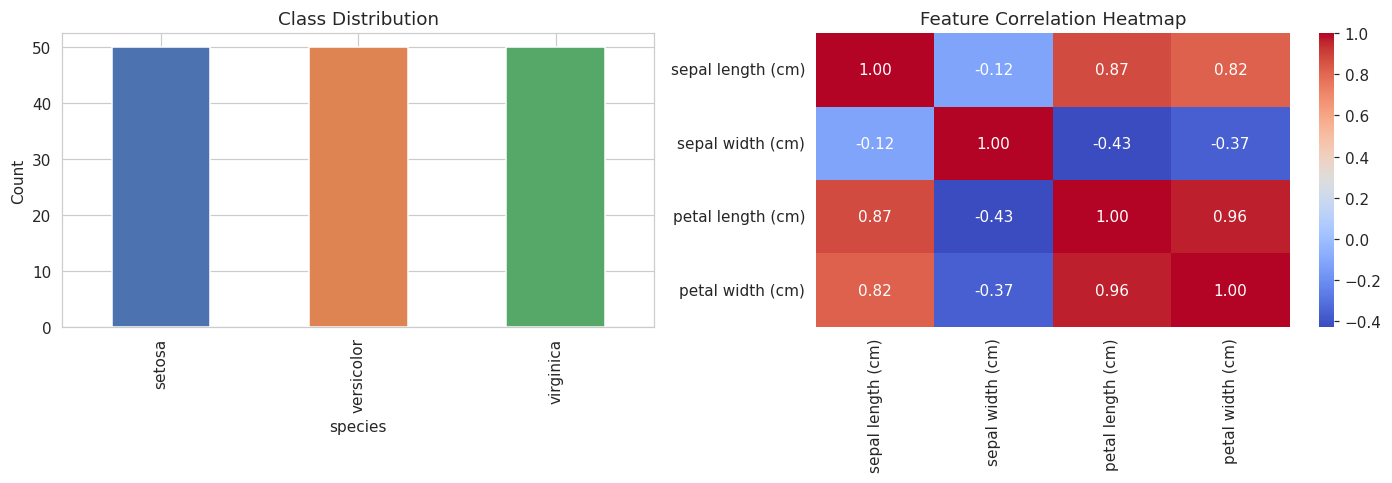

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

df['species'].value_counts().plot(kind='bar', ax=axes[0], color=['#4c72b0','#dd8452','#55a868'])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')

sns.heatmap(X.corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=axes[1])
axes[1].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

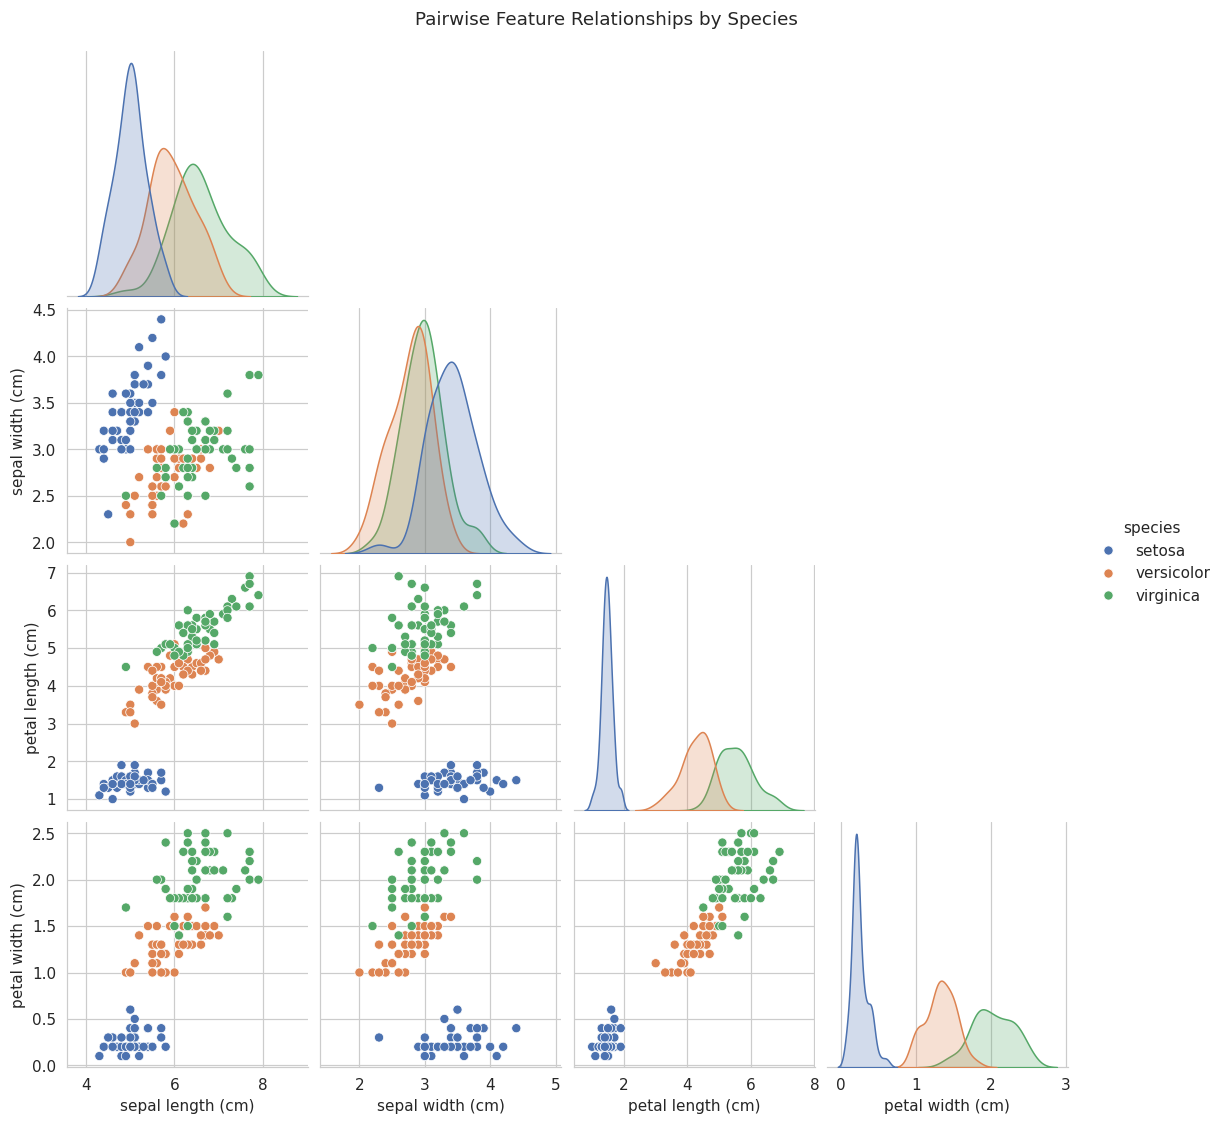

In [ ]:
sns.pairplot(df, hue='species', diag_kind='kde', palette='deep', corner=True)
plt.suptitle('Pairwise Feature Relationships by Species', y=1.02)
plt.show()

## 4. Preprocessing

### 4.1 Train / Test Split
Data is shuffled and split 80/20, using **stratification** so each class keeps its
proportion in both sets (important — the plain PDF brief skips this, but it's best
practice on real classification tasks).

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y, shuffle=True
)
print("Train size:", X_train.shape, " Test size:", X_test.shape)

Train size: (120, 4)  Test size: (30, 4)


### 4.2 Feature Scaling
`StandardScaler` is fit **only on the training data** and then applied to both sets,
to avoid data leakage from the test set into training.

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pd.DataFrame(X_train_scaled, columns=X.columns).describe().loc[['mean','std']]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
mean,-1.184238e-15,-1.998401e-15,4.958996e-16,1.669035e-15
std,1.004193e+00,1.004193e+00,1.004193e+00,1.004193e+00


## 5. Choosing K for KNN — The Elbow Method
We test K from 1 to 25 and track cross-validated error rate to find the "elbow"
(optimal K) instead of guessing.

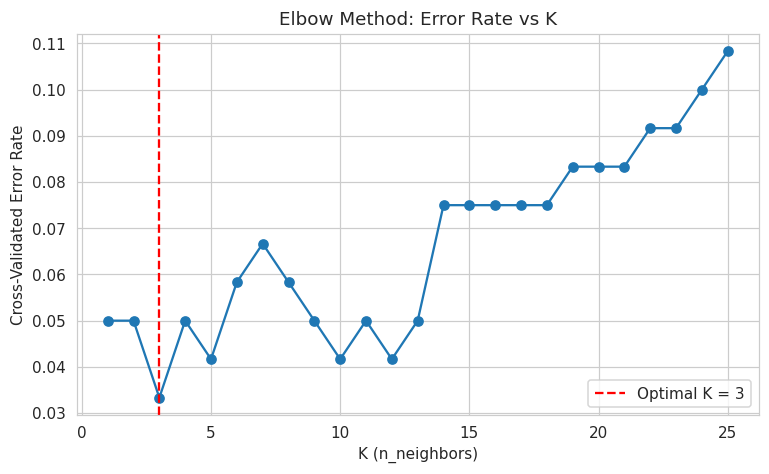

Optimal K selected: 3


In [ ]:
k_range = range(1, 26)
cv_errors = []

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=skf, scoring='accuracy')
    cv_errors.append(1 - scores.mean())

best_k = k_range[int(np.argmin(cv_errors))]

plt.figure(figsize=(8,4.5))
plt.plot(list(k_range), cv_errors, marker='o')
plt.axvline(best_k, color='red', linestyle='--', label=f'Optimal K = {best_k}')
plt.title('Elbow Method: Error Rate vs K')
plt.xlabel('K (n_neighbors)')
plt.ylabel('Cross-Validated Error Rate')
plt.legend()
plt.show()

print(f"Optimal K selected: {best_k}")

## 6. Model Comparison (Advanced Step)
Rather than relying on a single algorithm, we benchmark **5 classifiers** with
5-fold stratified cross-validation on the training set, to justify the final choice
with evidence instead of assumption.

In [ ]:
models = {
    "KNN (k=%d)" % best_k: KNeighborsClassifier(n_neighbors=best_k),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "SVM (RBF kernel)": SVC(kernel='rbf', random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "Naive Bayes": GaussianNB(),
}

results = []
for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=skf, scoring='accuracy')
    results.append({"Model": name, "Mean CV Accuracy": scores.mean(), "Std Dev": scores.std()})

results_df = pd.DataFrame(results).sort_values("Mean CV Accuracy", ascending=False).reset_index(drop=True)
results_df

,Model,Mean CV Accuracy,Std Dev
0,KNN (k=3),0.966667,0.016667
1,SVM (RBF kernel),0.966667,0.016667
2,Logistic Regression,0.958333,0.026352
3,Decision Tree,0.950000,0.016667
4,Random Forest,0.950000,0.031180
5,Naive Bayes,0.950000,0.016667


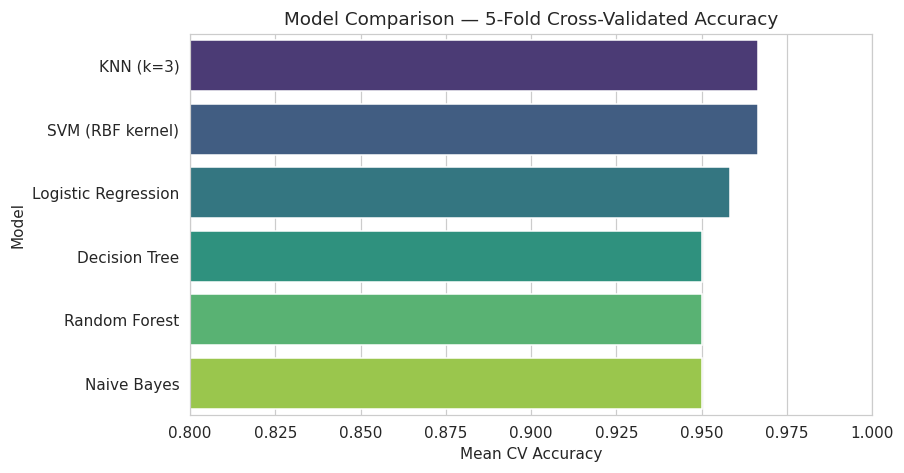

In [ ]:
plt.figure(figsize=(8,4.5))
sns.barplot(data=results_df, x="Mean CV Accuracy", y="Model", palette="viridis")
plt.xlim(0.8, 1.0)
plt.title("Model Comparison — 5-Fold Cross-Validated Accuracy")
plt.show()

## 7. Hyperparameter Tuning (GridSearchCV)
We take the top-performing model family and squeeze out extra performance with a
grid search over key hyperparameters.

In [ ]:
param_grid = {
    'n_neighbors': list(range(1, 21)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=skf, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_scaled, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV accuracy: %.4f" % grid.best_score_)

best_model = grid.best_estimator_

Best parameters: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
Best CV accuracy: 0.9667


## 8. Final Evaluation on the Held-Out Test Set (Output Stage)
The tuned model is now evaluated **once** on the untouched test set — the true
measure of generalization.

In [ ]:
y_pred = best_model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

print(f"Test Accuracy       : {acc:.4f}")
print(f"Test F1 (macro)      : {f1_macro:.4f}")
print(f"Test F1 (weighted)   : {f1_weighted:.4f}\n")
print("Full Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Test Accuracy       : 0.9333
Test F1 (macro)      : 0.9327
Test F1 (weighted)   : 0.9327

Full Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



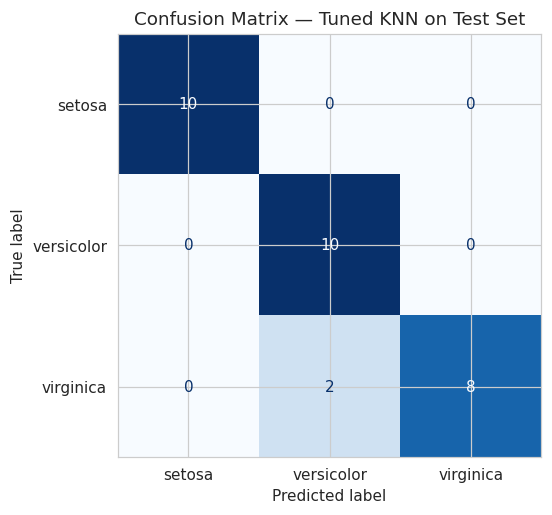

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)

fig, ax = plt.subplots(figsize=(6,5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title("Confusion Matrix — Tuned KNN on Test Set")
plt.show()

> **Why F1 & confusion matrix, not just accuracy?**
> As the brief itself warns, on imbalanced data "accuracy is a lie." Even though Iris
> is balanced, we still report precision/recall/F1 per class and the full confusion
> matrix, because in real-world classification tasks (medical, fraud, etc.) that is
> the standard of evidence — not a single accuracy number.

## 9. Decision Boundary Visualization
Using the two most discriminative features (petal length & petal width) to visualize
how the model partitions the feature space.

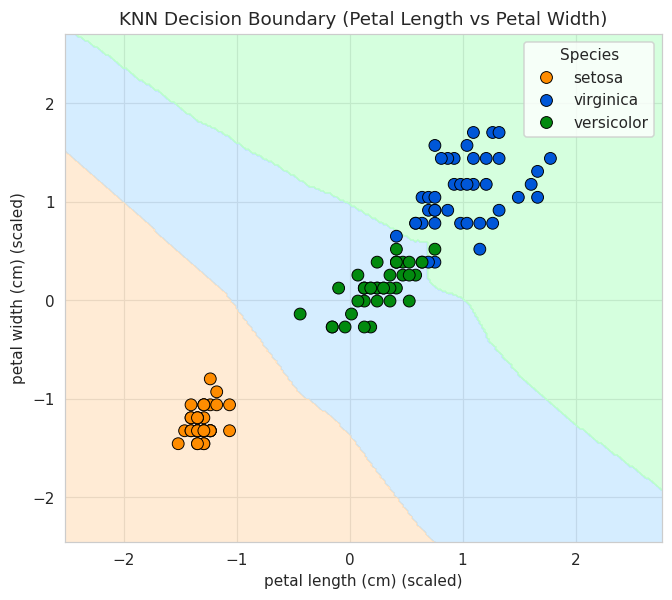

In [ ]:
from matplotlib.colors import ListedColormap

feat_x, feat_y = 'petal length (cm)', 'petal width (cm)'
X2 = X[[feat_x, feat_y]].values
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler2 = StandardScaler()
X2_train_s = scaler2.fit_transform(X2_train)
X2_test_s = scaler2.transform(X2_test)

model_2d = KNeighborsClassifier(**{k:v for k,v in grid.best_params_.items()})
model_2d.fit(X2_train_s, y2_train)

x_min, x_max = X2_train_s[:,0].min()-1, X2_train_s[:,0].max()+1
y_min, y_max = X2_train_s[:,1].min()-1, X2_train_s[:,1].max()+1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

cmap_light = ListedColormap(['#FFDFBA','#BAE1FF','#BAFFC9'])
cmap_bold = ['#FF8C00','#0057D8','#028A0F']

plt.figure(figsize=(7,6))
plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.6)
sns.scatterplot(x=X2_train_s[:,0], y=X2_train_s[:,1], hue=y_train.map(species_map),
                 palette=cmap_bold, edgecolor='k', s=60)
plt.xlabel(f'{feat_x} (scaled)')
plt.ylabel(f'{feat_y} (scaled)')
plt.title('KNN Decision Boundary (Petal Length vs Petal Width)')
plt.legend(title='Species')
plt.show()

## 10. Feature Importance (Random Forest, for interpretability)
Even though KNN was our final model, a Random Forest is fit here purely to inspect
*which features matter most* — a useful diagnostic in any real project.

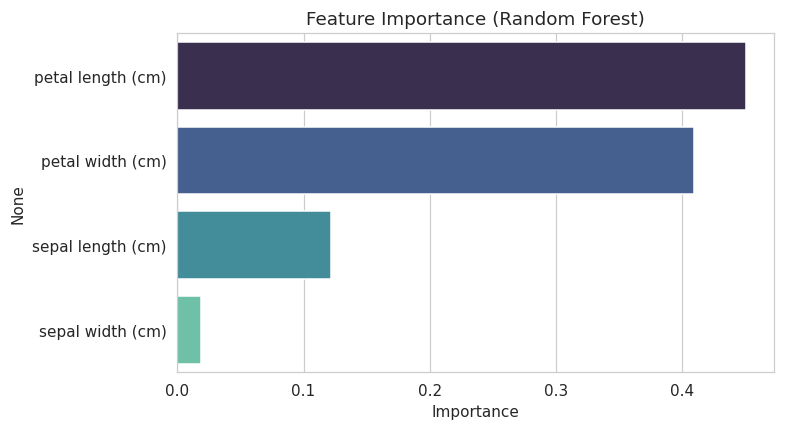

,0
petal length (cm),0.450316
petal width (cm),0.409548
sepal length (cm),0.121454
sepal width (cm),0.018682


In [ ]:
rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
rf.fit(X_train_scaled, y_train)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(7,4))
sns.barplot(x=importances.values, y=importances.index, palette='mako')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.show()

importances

## 11. Save the Final Model
Persisting the trained model and scaler so they can be reused for inference without
retraining.

In [ ]:
joblib.dump(best_model, 'iris_knn_model.joblib')
joblib.dump(scaler, 'iris_scaler.joblib')
print("Saved: iris_knn_model.joblib, iris_scaler.joblib")

Saved: iris_knn_model.joblib, iris_scaler.joblib


### Sample Inference
Demonstrating the saved model on a brand-new, unseen flower measurement.

In [ ]:
sample = pd.DataFrame([[5.1, 3.5, 1.4, 0.2]], columns=X.columns)  # looks like a Setosa
sample_scaled = scaler.transform(sample)
pred = best_model.predict(sample_scaled)[0]
print("Predicted species:", species_map[pred])

Predicted species: setosa


## 12. Conclusion

- Compared **6 classification algorithms** with 5-fold stratified cross-validation instead of committing to one blindly.
- Selected the optimal **K** for KNN using the elbow method, then refined it further with **GridSearchCV** across `n_neighbors`, `weights`, and `distance metric`.
- Evaluated the final model on a held-out test set using **accuracy, F1-score (macro & weighted), a full classification report, and a confusion matrix** — not accuracy alone.
- Visualized the **decision boundary** and **feature importances** for interpretability.
- Persisted the trained model with `joblib` for real-world reuse.

This pipeline mirrors an industry-grade supervised learning workflow (EDA → preprocessing → model selection → tuning → rigorous evaluation → interpretability → deployment-ready artifact), fulfilling and extending the Project 2 brief.
